# How K-means Finds the Middle of a Cluster

K-means puts points into groups (clusters). Every cluster has a **centre**, and the centre always sits in the
**middle** of its points.

Finding the middle only needs two things you already know: **adding up** and **dividing**. That is what this
notebook is about.

We will:

1. work out a normal average of some numbers
2. find the middle of three points, one small step at a time
3. turn that into a small function
4. use it to run k-means ourselves
5. check our answer against scikit-learn

Run each cell in order with Shift + Enter.

## 1. Setting up

In [1]:
import matplotlib.pyplot as plt

def draw(points, centres=None, title=""):
    """Draw some points, and any centres as large crosses."""
    plt.figure(figsize=(5, 4.5))
    for name, (x, y) in points.items():
        plt.scatter(x, y, s=120, color="#1F7A8C")
        plt.annotate(name, (x + 0.15, y + 0.15), fontsize=13)
    if centres:
        for (x, y) in centres:
            plt.scatter(x, y, s=400, marker="X", color="#D9480F", edgecolor="black")
    plt.xlim(0, 10)
    plt.ylim(0, 9)
    plt.xlabel("across (x)")
    plt.ylabel("up (y)")
    plt.grid(alpha=0.3)
    plt.title(title)
    plt.show()

---
## 2. Warm up: an ordinary average

The average of some numbers takes three steps:

1. **add** them up
2. **count** how many there are
3. **divide** the total by the count

Python has `sum` to add up and `len` to count.

In [2]:
numbers = [2, 4, 9]

total = sum(numbers)       # 2 + 4 + 9
count = len(numbers)       # how many numbers?
average = total / count

print("Total:  ", total)
print("Count:  ", count)
print("Average:", average)

Total:   15
Count:   3
Average: 5.0


The average is **5**. That is all the maths k-means needs. The rest of the notebook just uses it on points.

---
## 3. A point is just two numbers

A point on a grid has two numbers: how far **across** (x) and how far **up** (y). The point `(1, 2)` is 1 across
and 2 up.

Here is a group of three points. Imagine k-means has decided they belong in the same cluster.

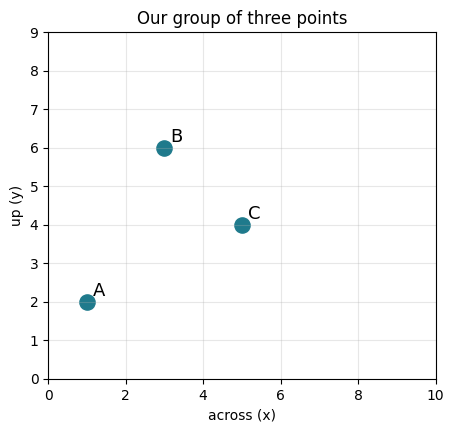

In [3]:
group = {"A": (1, 2), "B": (3, 6), "C": (5, 4)}

draw(group, title="Our group of three points")

Where is the middle? The trick is to deal with **across** and **up** separately.

### Step 1: take the across numbers

In [4]:
across = [x for (x, y) in group.values()]
print("Across numbers:", across)

Across numbers: [1, 3, 5]


### Step 2 and 3: add them up and divide by how many

In [5]:
middle_across = sum(across) / len(across)
print(sum(across), "/", len(across), "=", middle_across)

9 / 3 = 3.0


The middle is **3 across**.

### Step 4: do exactly the same for the up numbers

In [6]:
up = [y for (x, y) in group.values()]
middle_up = sum(up) / len(up)

print("Up numbers:", up)
print(sum(up), "/", len(up), "=", middle_up)

Up numbers: [2, 6, 4]
12 / 3 = 4.0


The middle is **4 up**.

### Step 5: put the two answers together

The centre is (3.0, 4.0)


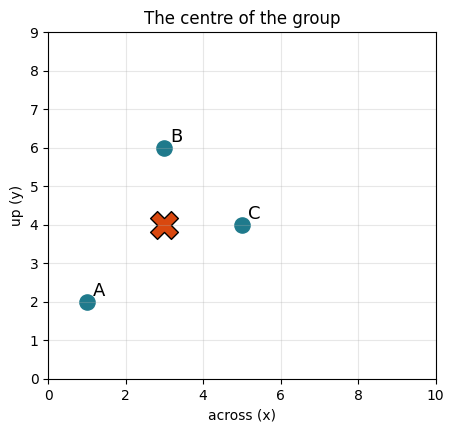

In [7]:
centre = (middle_across, middle_up)
print("The centre is", centre)

draw(group, centres=[centre], title="The centre of the group")

The cross at **(3, 4)** sits in the middle of the three points. This is the cluster's **centre** (also called the
**centroid**).

Why the average? It is the **balance point**: if you put the cross anywhere else, the points would be further
away from it overall. K-means wants every point to be as close as possible to its centre, so the average is
exactly what it needs.

---
## 4. Turning it into a function

We will need to find a middle many times, so let's wrap the five steps up in a function.

In [8]:
def find_middle(points):
    """Return the middle (average) of a list of (x, y) points."""
    across = [x for (x, y) in points]
    up = [y for (x, y) in points]
    return (sum(across) / len(across), sum(up) / len(up))

print(find_middle([(1, 2), (3, 6), (5, 4)]))

(3.0, 4.0)


### What happens when a point joins the group?

In k-means the groups keep changing. When they do, we just find the middle again. Here point D at (7, 8) joins.
Now there are four points, so we divide by 4.

New centre: (4.0, 5.0)


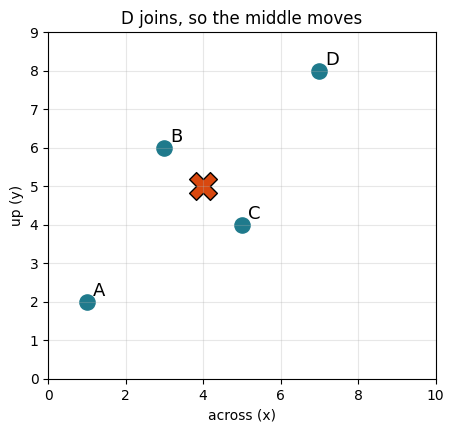

In [9]:
group["D"] = (7, 8)

new_centre = find_middle(list(group.values()))
print("New centre:", new_centre)

draw(group, centres=[new_centre], title="D joins, so the middle moves")

The centre moves from (3, 4) to **(4, 5)**: across is 16 / 4 = 4 and up is 20 / 4 = 5. It moves **towards** the
new point, because D pulls the balance point its way.

---
## 5. Using it to run k-means ourselves

K-means repeats two steps:

1. **Assign:** every point joins the centre it is **nearest** to.
2. **Update:** every centre moves to the **middle** of its points, using `find_middle`.

It stops when the centres stop moving.

For "nearest" we use ordinary straight-line distance. `math.dist` measures it for us, like using a ruler.

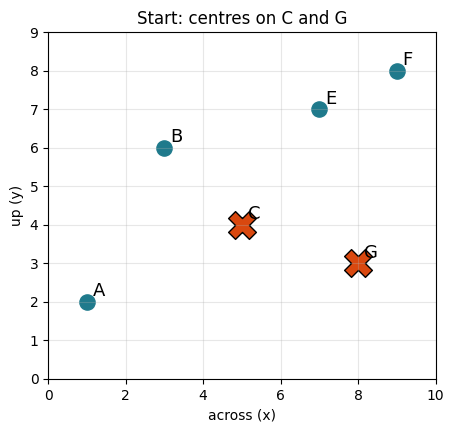

In [10]:
import math

points = {"A": (1, 2), "B": (3, 6), "C": (5, 4),
          "E": (7, 7), "F": (9, 8), "G": (8, 3)}

# Start the two centres on points C and G
centres = [(5, 4), (8, 3)]

draw(points, centres=centres, title="Start: centres on C and G")

Round 1: centres move from [(5, 4), (8, 3)] to [(4.0, 4.75), (8.5, 5.5)]


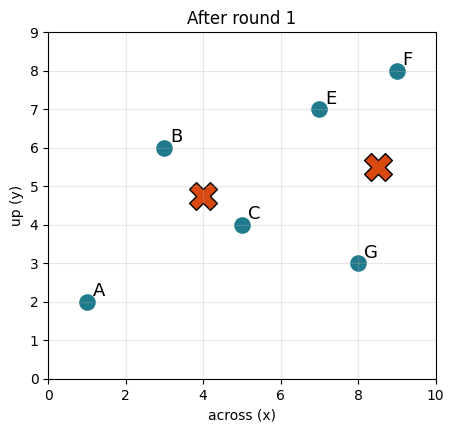

Round 2: centres move from [(4.0, 4.75), (8.5, 5.5)] to [(3.0, 4.0), (8.0, 6.0)]


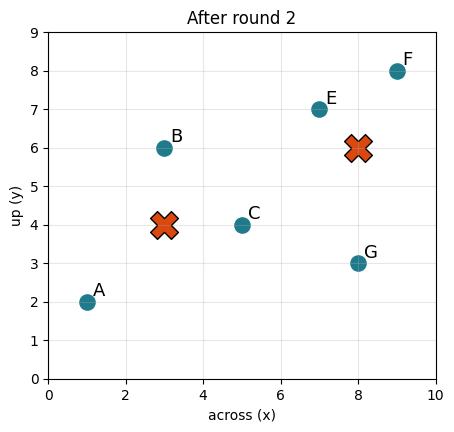

Round 3: centres move from [(3.0, 4.0), (8.0, 6.0)] to [(3.0, 4.0), (8.0, 6.0)]


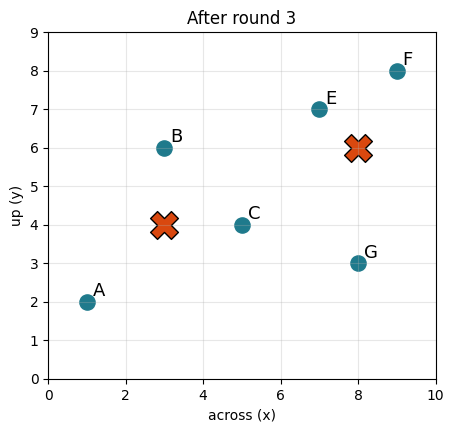

The centres did not move, so k-means is finished.


In [11]:
for round_number in range(1, 6):

    # Step 1: assign every point to its nearest centre
    groups = [[], []]
    for name, p in points.items():
        distances = [math.dist(p, c) for c in centres]
        nearest = distances.index(min(distances))
        groups[nearest].append(p)

    # Step 2: move each centre to the middle of its group
    new_centres = [find_middle(g) for g in groups]

    print(f"Round {round_number}: centres move from {centres} to {new_centres}")
    draw(points, centres=new_centres, title=f"After round {round_number}")

    if new_centres == centres:
        print("The centres did not move, so k-means is finished.")
        break
    centres = new_centres

### What happened

- **Round 1:** E was a little nearer C than G, so the first group was A, B, C and E. Its middle was pulled to the
  right, to (4, 4.75). The other group, F and G, had its middle at (8.5, 5.5).
- **Round 2:** now E is nearer the second centre, so it switches. The middles become **(3, 4)** and **(8, 6)**.
- **Round 3:** nobody switches, so the middles do not change and k-means stops.

Each centre was found with nothing more than **add up and divide**, once for across and once for up.

---
## 6. Checking with scikit-learn

scikit-learn's `KMeans` does exactly the same thing. Let's check it finds the same centres.

In [12]:
from sklearn.cluster import KMeans

X = list(points.values())
km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(X)

print("scikit-learn centres:")
print(km.cluster_centers_)

scikit-learn centres:
[[8. 6.]
 [3. 4.]]


The same two centres, **(3, 4)** and **(8, 6)** (they may be listed the other way round). Behind the scenes,
`KMeans` is doing the same assign and update steps that we wrote above.

---
## 7. Try it yourself

1. Use `find_middle` to find the middle of P (2, 1), Q (4, 3) and R (6, 8). Work it out on paper first, then check.
2. Add a fourth point, S (8, 0), to the list. Before you run it, guess which way the middle will move.
3. In Section 5, change the starting centres to `[(1, 2), (3, 6)]` (points A and B) and run both cells again.
   Do you get the same answer? Why might k-means get stuck when both centres start in the same corner?

In [13]:
# Your code here

## Summary

To find the middle of a cluster:

1. Add up the **across** numbers and divide by how many points there are.
2. Add up the **up** numbers and divide by how many points there are.
3. Those two answers together are the **centre**.

K-means does this for every cluster, every round, until the points stop switching clusters.